# ETFs: Feature Engineering

Every model here sees the world through this matrix, so what is computable now bounds what
can be learned later. Each feature answers one question: at the moment a position is decided,
which observations are already on the tape, and what does the feature make of them?

## Learning objectives

- State a feature's timing contract - its lookback and its information lag - before writing
  the code that computes it
- Compute trailing and cross-sectional statistics that read no observation dated at or after
  the decision timestamp
- Show that withholding later dates leaves every feature value unchanged, which is what
  separates a trailing statistic from one fitted over the whole sample
- Read a feature set for scale, dispersion, redundancy and decay before any model sees it

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads split- and dividend-adjusted daily bars via `load_etfs()`,
the Treasury constant-maturity series via `load_macro()`, the tradability gate
`eligibility.csv` from [`01_feasibility_analysis`](01_feasibility_analysis.ipynb), and
`config/setup.yaml`. Writes `features/financial.parquet` with a `.digest.json` sidecar, read
by [`04_model_based_features`](04_model_based_features.ipynb), which builds regime and
memory-preserving features on top of it, and by
[`05_evaluation`](05_evaluation.ipynb), which tests fold by fold whether any of it predicts.

In [1]:
"""ETFs: Feature Engineering."""

import warnings
from datetime import date

import polars as pl
import yaml
from ml4t.engineer.features.momentum import adx, aroon, cci, macd, rsi, stochastic
from ml4t.engineer.features.regime import choppiness_index, hurst_exponent
from ml4t.engineer.features.trend import ema, sma
from ml4t.engineer.features.volatility import natr
from ml4t.engineer.features.volume import obv

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    cross_sectional_percentile,
    drawdown_block,
    families_from_config,
    family_coverage,
    momentum_volatility_block,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    relative_volume_block,
    warmup_audit,
)
from data import load_etfs, load_macro
from utils.artifact_specs import resolve_label_horizon
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("etfs")
FEATURES_DIR = CASE_DIR / "features"

In [2]:
# Production runs START_DATE as None; CI overrides it to shorten the window. The CI fixture is
# already reduced in breadth, so there is no symbol cap here - the cross-sectional families
# below need a cross-section to rank within.
START_DATE = None

## Configuration

Every window, the ranked feature list, the regime threshold, the decision horizon and the
holdout boundary are declared in `config/setup.yaml` and bound here. A value the notebook
invents is a second source of truth for a decision the rest of the pipeline reads from one
place. The horizon fixes how far the persistence figure has to look, because a feature has to
hold its ordering for at least one decision cycle to be usable at that cadence.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FAMILIES = families_from_config(setup)
WINDOWS = setup["features"]["windows"]
RANKED = setup["features"]["ranked"]
REGIME_THRESHOLD = setup["features"]["regime_threshold"]
DECISION_CYCLE = int(resolve_label_horizon("etfs", setup["labels"]["primary"], setup).rstrip("Dd"))
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])

print(f"{len(FAMILIES)} declared families, decision cycle {DECISION_CYCLE} sessions")
print(f"Holdout starts {HOLDOUT_START}; Section D rebuilds the panel without it")

9 declared families, decision cycle 21 sessions
Holdout starts 2024-01-01; Section D rebuilds the panel without it


## A. What the thesis says should carry information

The hypothesis is cross-sectional and it is about persistence: among liquid ETFs spanning
equities, bonds, commodities and currencies, the ones that have gained relative to the rest
continue to over the following month. Three things follow.

The **carrier** is trailing relative performance, so the matrix holds returns and
risk-adjusted returns at eight horizons rather than one - which horizon the effect lives at
is an empirical question, not a modelling assumption. The skip-recent construction drops the
most recent month from the long window, because that month reverses where the twelve before
it continue.

The **conditioning** is regime: a cross-asset rotation only works while the assets disagree,
so the matrix also carries volatility, drawdown, trend strength, the equity-bond correlation
and the shape of the yield curve. These rank nothing against each other; they say which
environment a ranking is being formed in, which is what the register's `role` column records
and what no assertion can recover from the values.

The **representation** matters as much as the quantity. A raw return has a distribution that
drifts with the volatility of the period, so the three carrier features are also carried as
cross-sectional percentiles, comparable across dates by construction.

The register is declared in `config/setup.yaml`, one row per family: what it reads, how far
back, and with what delay. A `lag` of zero means the input is on the tape at the decision
itself, and every family here is zero - the decision is taken at the close, the Treasury
series publishes at the end of the session it describes, and execution is at the next open.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,inputs,lookback (bars),lag (bars),frame
str,str,str,i64,i64,str
"""momentum""","""signal""","""adjusted close""",252,0,"""time series"""
"""risk-adjusted momentum""","""signal""","""log return""",252,0,"""time series"""
"""volatility""","""state""","""log return""",252,0,"""time series"""
"""oscillator and trend""","""signal""","""OHLC""",200,0,"""time series"""
"""range and drawdown""","""state""","""OHLC""",126,0,"""time series"""
"""volume""","""state""","""share volume""",63,0,"""time series"""
"""extremes and consistency""","""signal""","""adjusted close""",252,0,"""time series"""
"""cross-sectional position""","""signal""","""carrier features""",252,0,"""cross-section"""
"""macro and cross-asset regime""","""state""","""SPY and TLT log returns, 10y a…",252,0,"""cross-asset"""


## B. Inputs and their observability

Daily bars are split- and dividend-adjusted, so a trailing return spans a corporate action
without a jump. Eligibility is a per-year tradability gate holding the cross-section to ETFs
that traded at volume that year, rather than letting a fund listed in 2019 appear in a 2011
ranking. The Treasury series skips market holidays, which is why C.4 joins it backward in time
rather than on an exact date.

In [5]:
prices = (
    load_etfs()
    .select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])
    .sort(["symbol", "timestamp"])
)
if START_DATE is not None:
    prices = prices.filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())

eligibility = pl.read_csv(CASE_DIR / "eligibility.csv")
yield_curve = (
    load_macro()
    .select("timestamp", ((pl.col("dgs10") - pl.col("dgs2")) / 100).alias("slope"))
    .drop_nulls()
    .sort("timestamp")
)
print(f"{len(prices):,} bars over {prices['symbol'].n_unique()} ETFs")
print(f"{len(yield_curve):,} sessions of 10y-2y spread")

470,662 bars over 100 ETFs
9,495 sessions of 10y-2y spread


## C. Feature construction, one subsection per family

### C.1 Momentum, volatility and their differences

The trailing return, volatility and risk-adjusted return block is shared with the other
panel case studies, because three of them had computed it character for character with five
different denominator guards between them. What stays here is what is specific to this
universe: the skip-recent windows, the differences between horizons, and the ratio of a short
volatility window to a long one.

In [6]:
def momentum_features(df: pl.DataFrame) -> pl.DataFrame:
    """The shared trailing block, plus the differences this case study builds on it."""
    df = momentum_volatility_block(
        df,
        entity="symbol",
        return_windows=WINDOWS["momentum"],
        volatility_windows=WINDOWS["volatility"],
    )
    held = pl.col("close").shift(WINDOWS["skip_recent"]).over("symbol")
    return df.with_columns(
        (held / pl.col("close").shift(252).over("symbol").clip(lower_bound=EPS) - 1).alias(
            "skip_recent_12_1"
        ),
        (held / pl.col("close").shift(126).over("symbol").clip(lower_bound=EPS) - 1).alias(
            "skip_recent_6_1"
        ),
        (pl.col("ret_21d") - pl.col("ret_63d")).alias("mom_accel_short"),
        (pl.col("ret_63d") - pl.col("ret_126d")).alias("mom_accel_medium"),
        (pl.col("ret_126d") - pl.col("ret_252d")).alias("mom_accel_long"),
        (pl.col("vol_21d") / pl.col("vol_63d").clip(lower_bound=EPS)).alias("vol_ratio_short"),
        (pl.col("vol_63d") / pl.col("vol_126d").clip(lower_bound=EPS)).alias("vol_ratio_medium"),
    )

### C.2 Oscillators, trend ratios and range

These come from `ml4t.engineer.features` rather than being written here. The smoothing
convention inside an oscillator is where two implementations of one name diverge - Wilder's
recursive average and a simple moving average of the same gains give different numbers - and
a shared implementation is what keeps `rsi_14` meaning one thing across the nine case studies.

In [7]:
def oscillator_features(df: pl.DataFrame) -> pl.DataFrame:
    """Bounded oscillators, moving-average ratios, normalized range and regime exponents."""
    df = df.with_columns(
        rsi("close", period=7).over("symbol").alias("rsi_7"),
        rsi("close", period=14).over("symbol").alias("rsi_14"),
        macd("close", fast_period=12, slow_period=26).over("symbol").alias("macd_line"),
        adx("high", "low", "close", period=14).over("symbol").alias("adx_14"),
        cci("high", "low", "close", period=14).over("symbol").alias("cci_14"),
        cci("high", "low", "close", period=21).over("symbol").alias("cci_21"),
        stochastic("high", "low", "close", fastk_period=14).over("symbol").alias("stoch_k"),
        aroon("high", "low", timeperiod=25).over("symbol").alias("_aroon"),
        natr("high", "low", "close", period=14).over("symbol").alias("natr_14"),
        choppiness_index("high", "low", "close", period=14).over("symbol").alias("chop_14"),
        hurst_exponent("close", period=100).over("symbol").alias("hurst_100"),
        (pl.col("close") / sma("close", period=50).over("symbol")).alias("sma_ratio_50"),
        (pl.col("close") / sma("close", period=200).over("symbol")).alias("sma_ratio_200"),
        (pl.col("close") / ema("close", period=26).over("symbol")).alias("ema_ratio_26"),
        pl.col("close").rolling_mean(20).over("symbol").alias("_mid"),
        pl.col("close").rolling_std(20).over("symbol").alias("_sd"),
    )
    return df.with_columns(
        (pl.col("_aroon").struct.field("up") - pl.col("_aroon").struct.field("down")).alias(
            "aroon_diff"
        ),
        pl.when(pl.col("_sd") > 0)
        .then((pl.col("close") - (pl.col("_mid") - 2 * pl.col("_sd"))) / (4 * pl.col("_sd")))
        .alias("bb_pctb_20"),
    ).drop(["_aroon", "_mid", "_sd"])

### C.3 Drawdown, volume and distance from extremes

`max_dd_63d` is the share by which price currently sits below its highest close of the
trailing quarter, so it is zero at a new high and negative otherwise - the *current*
drawdown, not the worst decline inside the window, which is a different statistic. Relative
volume is clipped at the 1st and 99th percentile of its own date, because an index rebalance
puts one ETF orders of magnitude above its own average and one such row otherwise sets the
scale every model sees.

In [8]:
def state_features(df: pl.DataFrame) -> pl.DataFrame:
    """Drawdown, relative volume, on-balance volume and position in the 52-week range."""
    df = drawdown_block(df, entity="symbol", windows=WINDOWS["drawdown"])
    df = relative_volume_block(df, entity="symbol", windows=WINDOWS["volume"])
    df = df.with_columns(obv("close", "volume").over("symbol").alias("_obv"))
    return df.with_columns(
        (
            (pl.col("_obv") - pl.col("_obv").rolling_mean(63).over("symbol"))
            / pl.col("_obv").rolling_std(63).over("symbol").clip(lower_bound=EPS)
        ).alias("obv_zscore_63d"),
        (pl.col("log_return") > 0)
        .cast(pl.Float64)
        .rolling_mean(63)
        .over("symbol")
        .alias("pct_positive_63d"),
        (
            pl.col("close") / pl.col("close").rolling_max(252).over("symbol").clip(lower_bound=EPS)
        ).alias("dist_52w_high"),
        (
            pl.col("close") / pl.col("close").rolling_min(252).over("symbol").clip(lower_bound=EPS)
        ).alias("dist_52w_low"),
    ).drop("_obv")

### C.4 Cross-asset state, macro state and cross-sectional position

The SPY-TLT correlation and the curve slope are one number per date, shared by every ETF. A
rolling window reads row order rather than the timestamp column, so the pair is re-sorted after
the join that builds it, and the curve joins backward in time so a market holiday carries the
previous session's spread forward and never a later one's. Three carrier features are then also
carried as their percentile within the date; ranking all eight horizons would add nothing,
because eight highly correlated returns carry one ordering between them.

In [9]:
def regime_and_position(df: pl.DataFrame) -> pl.DataFrame:
    """Equity-bond correlation, yield-curve state, and percentile within the date."""
    pair = (
        df.filter(pl.col("symbol") == "SPY")
        .select("timestamp", pl.col("log_return").alias("_spy"))
        .join(
            df.filter(pl.col("symbol") == "TLT").select(
                "timestamp", pl.col("log_return").alias("_tlt")
            ),
            on="timestamp",
            how="inner",
        )
        .sort("timestamp")
        .select(
            "timestamp",
            pl.rolling_corr(pl.col("_spy"), pl.col("_tlt"), window_size=63).alias(
                "corr_spy_tlt_63d"
            ),
        )
    )
    curve = yield_curve.select(
        "timestamp",
        pl.when(pl.col("slope") > REGIME_THRESHOLD).then(1).otherwise(0).alias("regime"),
        pl.col("slope").alias("yield_curve_slope"),
        (
            (pl.col("slope") - pl.col("slope").rolling_mean(252))
            / pl.col("slope").rolling_std(252).clip(lower_bound=EPS)
        ).alias("yield_curve_zscore"),
    )
    return (
        df.join(pair, on="timestamp", how="left")
        .sort("timestamp")
        .join_asof(curve, on="timestamp", strategy="backward")
        .with_columns(
            cross_sectional_percentile(col, "timestamp").alias(f"{col}_rank") for col in RANKED
        )
    )


def build_features(df: pl.DataFrame) -> pl.DataFrame:
    """The whole construction, as one function Section D can re-run on a shorter panel."""
    return (
        df.pipe(momentum_features)
        .pipe(oscillator_features)
        .pipe(state_features)
        .pipe(regime_and_position)
    )


built = build_features(prices)
print(f"{len(built):,} bars carrying {built.width - 8} features")

2026-07-30 21:55:02 | mlquant.features.adx | INFO | [ADX] Starting calculation with parameters: period=14 (shape: (4,))


2026-07-30 21:55:02 | mlquant.features.adx | INFO | [ADX] Completed calculation (shape: (4,)) (0.13ms)


470,662 bars carrying 57 features


## D. The timing contract

### D.1 What each construction reads

Three kinds of operation appear above. A **rolling** window ends at its own row and reads a
fixed number of bars backward. A **cross-sectional** statistic - the three percentiles, and
the volume clip - is taken with `.over("timestamp")`, so it reads every ETF on that date and
no other. An **as-of join** carries the most recent macro value at or before the row's
timestamp. D.2 and D.3 establish that none of the three reaches forward.

### D.2 Warmup

A trailing window cannot produce a value until it has enough bars to fill, so every family has
a leading stretch of nulls as long as its lookback. The audit checks that length rather than
describing it: a column carrying a value before its window could have filled is reading bars
that do not exist, and that is the failure it raises on.

In [10]:
warmup_audit(
    built,
    {
        "ret_252d": 252,
        "skip_recent_12_1": 252,
        "sharpe_252d": 252,
        "vol_252d": 252,
        "dist_52w_high": 252,
        "sma_ratio_200": 200,
        "max_dd_126d": 126,
        "hurst_100": 100,
        "obv_zscore_63d": 63,
    },
    entity="symbol",
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""ret_252d""",252,253,true
"""skip_recent_12_1""",252,253,true
"""sharpe_252d""",252,253,true
"""vol_252d""",252,253,true
"""dist_52w_high""",252,252,true
"""sma_ratio_200""",200,200,true
"""max_dd_126d""",126,126,true
"""hurst_100""",100,100,true
"""obv_zscore_63d""",63,63,true


### D.3 Withholding the holdout changes nothing

Trailing and within-date statistics share a property worth checking directly: recomputed on a
panel that stops before the holdout, they reproduce the same values on the rows the two panels
share. A parameter fitted over a whole column - a winsorization bound, a scaler, an encoder -
does not, because truncating the column moves the parameter and with it every row it was
applied to. Building the panel twice and comparing tests the whole construction at once, and
does not depend on anyone having flagged the transform that fits.

In [11]:
assert_values_agree(
    built.filter(pl.col("timestamp") < HOLDOUT_START),
    build_features(prices.filter(pl.col("timestamp") < HOLDOUT_START)),
    columns=["ret_126d", "sharpe_126d", "vol_ratio_21d", "ret_126d_rank", "yield_curve_zscore"],
    keys=["timestamp", "symbol"],
)

2026-07-30 21:56:02 | mlquant.features.adx | INFO | [ADX] Starting calculation with parameters: period=14 (shape: (4,))


2026-07-30 21:56:02 | mlquant.features.adx | INFO | [ADX] Completed calculation (shape: (4,)) (0.06ms)


column,max abs difference
str,f64
"""ret_126d""",0.0
"""sharpe_126d""",0.0
"""vol_ratio_21d""",0.0
"""ret_126d_rank""",0.0
"""yield_curve_zscore""",0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. Raw OHLC, volume and the intermediate log return are
excluded: they are the inputs the features are made of, and a model handed the contemporaneous
log return beside a label derived from the same prices would be reading its own answer. One
null policy is applied once - a row is kept when the longest carrier feature has warmed up,
which is the point past which every family is dense.

In [12]:
EXCLUDED = {"symbol", "timestamp", "open", "high", "low", "close", "volume", "log_return"}
feature_cols = [c for c in built.columns if c not in EXCLUDED]

eligible = (
    built.with_columns(pl.col("timestamp").dt.year().alias("_year"))
    .join(
        eligibility.select("symbol", pl.col("eligible_year").alias("_year")),
        on=["symbol", "_year"],
        how="semi",
    )
    .select(["timestamp", "symbol", *feature_cols])
    .sort(["timestamp", "symbol"])
)
features = eligible.drop_nulls(subset=["sharpe_126d"])
assert features.select(["timestamp", "symbol"]).is_duplicated().sum() == 0, "duplicate panel key"
assignment = assign_families(feature_cols, FAMILIES)
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

family,columns,role,representation
str,i64,str,str
"""momentum""",13,"""signal""","""simple return, and differences…"
"""risk-adjusted momentum""",8,"""signal""","""window return over its own dis…"
"""volatility""",6,"""state""","""annualized standard deviation,…"
"""oscillator and trend""",12,"""signal""","""bounded oscillator, ratio to a…"
"""range and drawdown""",5,"""state""","""normalized range, Hurst expone…"
"""volume""",3,"""state""","""ratio to trailing mean, z-scor…"
"""extremes and consistency""",3,"""signal""","""ratio to a rolling extreme, sh…"
"""cross-sectional position""",3,"""signal""","""percentile within the decision…"
"""macro and cross-asset regime""",4,"""state""","""rolling correlation, level, z-…"


### F1. Coverage through time

The axis is scaled to the data, not pinned to zero: this matrix is dense everywhere, and on a
zero-based axis every family would draw as one flat line at the top. What is left to see is
where the residual percent sits, and it sits in the families with the longest windows - an ETF
admitted by the eligibility gate partway through a year has not yet filled a 252-session
lookback.

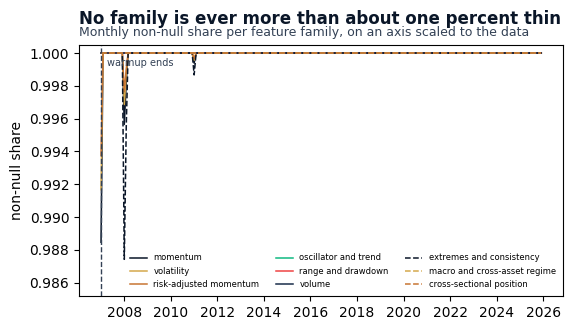

In [13]:
plot_coverage_through_time(
    family_coverage(features, assignment, every="1mo"),
    warmup_boundary=features["timestamp"].min(),
    title="No family is ever more than about one percent thin",
    subtitle="Monthly non-null share per feature family, on an axis scaled to the data",
    alt=(
        "Line chart of non-null share by feature family on a y-axis spanning roughly 0.985 to "
        "one. Most families sit exactly at one throughout. The long-window families - momentum, "
        "risk-adjusted momentum, extremes - dip by up to about one percent in scattered months, "
        "and no family is ever materially incomplete."
    ),
)

### F4. The timing contract

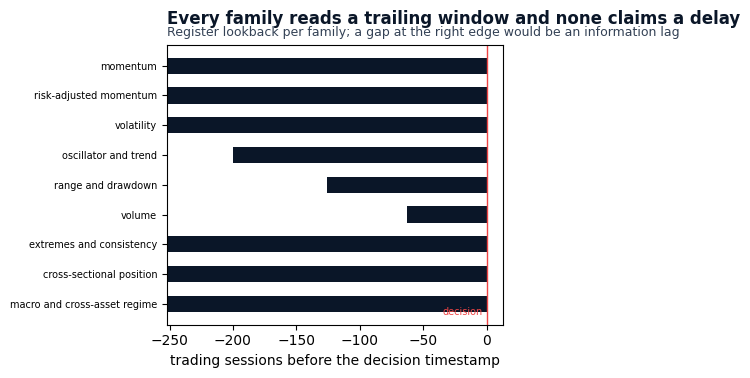

In [14]:
plot_timing_contract(
    FAMILIES,
    bar_unit="trading sessions",
    title="Every family reads a trailing window and none claims a delay",
    subtitle="Register lookback per family; a gap at the right edge would be an information lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision "
        "line by that family's lookback, from 63 sessions for volume to 252 for momentum and "
        "the macro state. No bar stops short of the decision line."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives
on, whether the cross-section disagrees enough to rank on, how much of the set is one ordering
under several names, and how long a value lasts. `05_evaluation` is where the matrix is tested
fold by fold for whether any of it predicts.

### F2. Feature distributions

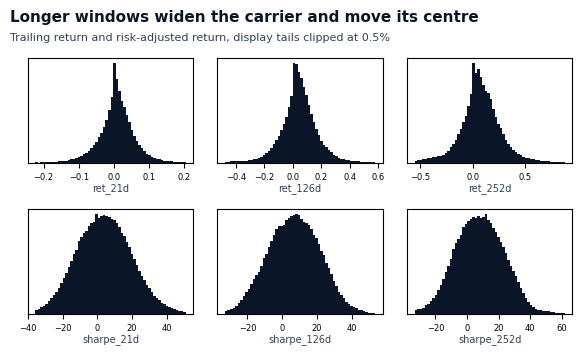

In [15]:
plot_feature_distributions(
    features,
    ["ret_21d", "ret_126d", "ret_252d", "sharpe_21d", "sharpe_126d", "sharpe_252d"],
    title="Longer windows widen the carrier and move its centre",
    subtitle="Trailing return and risk-adjusted return, display tails clipped at 0.5%",
    alt=(
        "Six histograms in two rows. The trailing returns along the top broaden from a narrow "
        "right-skewed peak at 21 sessions to a wide body at 252. The risk-adjusted returns "
        "below are close to symmetric at every horizon and an order of magnitude wider in scale."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band
narrows to nothing there is nothing to rank, whatever the average level of the feature.

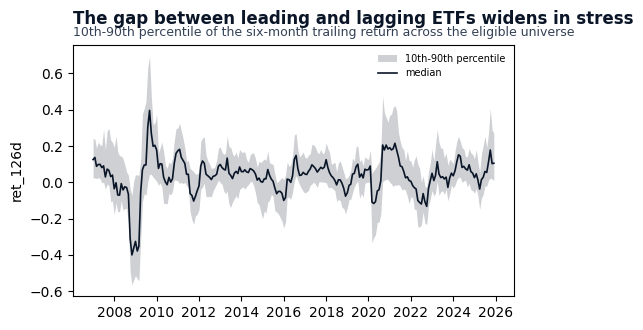

In [16]:
plot_cross_sectional_dispersion(
    features,
    "ret_126d",
    every="1mo",
    title="The gap between leading and lagging ETFs widens in stress",
    subtitle="10th-90th percentile of the six-month trailing return across the eligible universe",
    alt=(
        "Shaded band of the 10th to 90th percentile of six-month trailing return by month, with "
        "the median drawn through it. The band is a few tens of percent wide in calm periods "
        "and widens sharply in 2020 and again in 2022."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering, whatever
the sign. Above the cut two features are close enough that a linear model cannot separate
their contributions. This states the clusters; choosing one representative from each needs a
fold-aware criterion and belongs to `05_evaluation`.

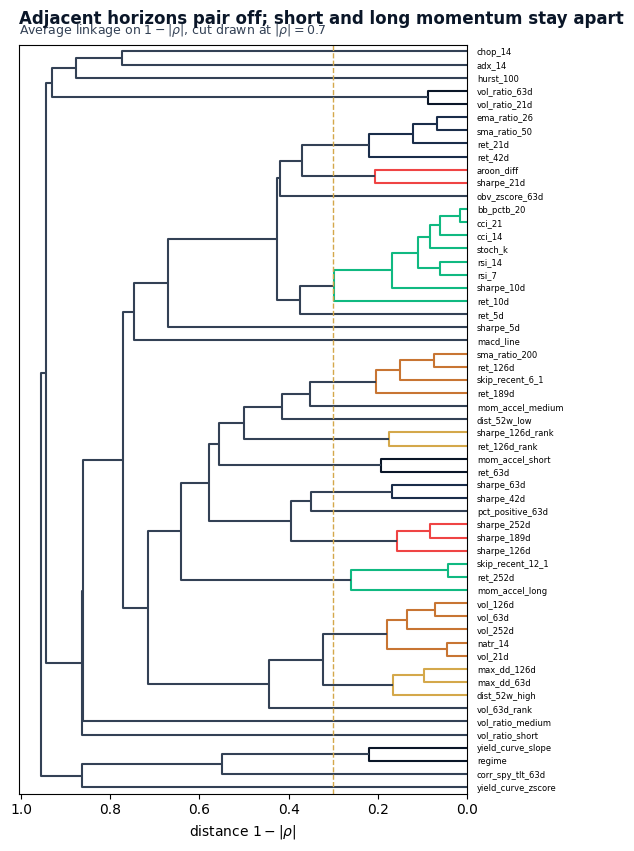

In [17]:
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=0.7,
    title="Adjacent horizons pair off; short and long momentum stay apart",
    subtitle=r"Average linkage on $1 - |\rho|$, cut drawn at $|\rho| = 0.7$",
    alt=(
        "Dendrogram of every feature in the matrix. Neighbouring horizons join at very small "
        "distances - the five- and ten-day returns with their risk-adjusted twins, the six- and "
        "nine-month returns with the 200-day trend ratio - but the short-horizon block and the "
        "long-horizon block only merge near the root, and the volatility, oscillator and macro "
        "features attach as separate branches."
    ),
)

### F6. Persistence and rank stability

The autocorrelation is of the feature, not of the return, and it runs past one full decision
cycle. A feature whose value has decayed inside a cycle cannot support that rebalance cadence,
however well it predicts on the day it is computed. The right-hand panel asks the same question
of the ordering rather than the level.

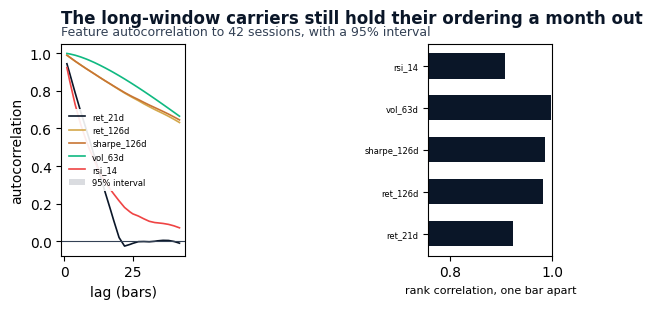

In [18]:
plot_persistence(
    features,
    ["ret_21d", "ret_126d", "sharpe_126d", "vol_63d", "rsi_14"],
    entity="symbol",
    max_lag=2 * DECISION_CYCLE,
    title="The long-window carriers still hold their ordering a month out",
    subtitle=f"Feature autocorrelation to {2 * DECISION_CYCLE} sessions, with a 95% interval",
    alt=(
        "Two panels. On the left, autocorrelation against lag: the six-month return and its "
        "risk-adjusted twin stay above 0.6 out to 42 sessions, while the one-month return "
        "reaches zero at exactly 21 and the 14-day oscillator is near zero soon after. On the "
        "right, one-session rank correlation, above 0.85 for all five features."
    ),
)

## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and key
columns, and the digests of what it was built from. The digest is computed over content rather
than file bytes, so row order and parquet metadata leave it alone and any feature value moves
it. That is the property the registry's own hashes lack: a feature-set *name* reaches the
registry, a feature-set *value* does not, so a corrected feature moves every number downstream
without changing anything the registry stores.

In [19]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=["symbol", "timestamp"],
    written_by="case_studies/etfs/03_financial_features.py",
    inputs={
        "eligibility.csv": value_digest(eligibility),
        "load_etfs": value_digest(prices),
        "load_macro:dgs10-dgs2": value_digest(yield_curve),
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}")

Wrote case_studies/etfs/features/financial.parquet


The matrix carries **57 features** on **396,186 rows** across **99 ETFs**, from **2007-01-03**
to **2025-12-31**, under content digest **8d691ca913ee2a81**. Cutting the redundancy tree
leaves **28 clusters**, so half the columns repeat an ordering another column already
carries.

In [20]:
print(f"{len(feature_cols)} features, {len(features):,} rows, {features['symbol'].n_unique()} ETFs")
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, digest {record['digest']}")
print(f"{len(set(clusters.values()))} redundancy clusters")

57 features, 396,186 rows, 99 ETFs
2007-01-03 to 2025-12-31, digest 8d691ca913ee2a81
28 redundancy clusters


## Key takeaways

- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion, the timing figure and the
  review a reader can run all read those numbers rather than re-deriving them from the code.
- **Test the seal by construction, not by inspection.** Rebuilding the panel with later dates
  withheld and comparing values catches any transform that fits across the sample, including
  the ones nobody thought to flag.
- **Rank inside the date.** A percentile taken within one timestamp is comparable across dates
  in a way a raw level, whose distribution drifts with the period's volatility, is not.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the rebalance cycle cannot be traded at that cadence.

### Known limitations

- The cross-asset regime feature is one pair, SPY against TLT. It describes the equity-bond
  relationship and says nothing about commodities or currencies, which are a third of the
  universe.
- The eligibility gate is annual, so an ETF that lost liquidity in June stays in the
  cross-section until December.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.